# Notebook 05: Hypothesis Testing Framework
#
 Two analyses:
1. Bin-level Z-tests with Bonferroni correction — which specific confidence bins are statistically significantly miscalibrated?
 2. Bootstrap confidence interval on ECE — how certain are we   about our ECE = 0.1760 estimate?
#

  Z-test for proportions, p-values, Type I error,
  Bonferroni correction for multiple comparisons
#

   Bootstrap resampling, percentile confidence intervals

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120
matplotlib.rcParams['font.size'] = 11
from scipy.stats import norm
import os

# ── Constants ────────────────────────────────────────────────────────────────
N_BINS         = 10
N_BOOTSTRAP    = 2000
ALPHA          = 0.01   # medical research threshold (stricter than 0.05)
BONFERRONI_ALPHA = ALPHA / N_BINS  # 0.01/10 = 0.001 — corrected threshold

# Load scores
df     = pd.read_csv("../data/scores.csv")
y_true = df["ground_truth"].values
y_prob = df["confidence_score"].values

print(f"Loaded {len(df):,} samples")
print(f"Significance level:          alpha = {ALPHA}")
print(f"Number of bins being tested: {N_BINS}")
print(f"Bonferroni corrected alpha:  {BONFERRONI_ALPHA}")
print()
print("Why Bonferroni? Running 10 simultaneous tests inflates")
print("Type I error rate. Bonferroni controls this by dividing")
print(f"alpha by number of tests: {ALPHA}/{N_BINS} = {BONFERRONI_ALPHA}")

Loaded 10,000 samples
Significance level:          alpha = 0.01
Number of bins being tested: 10
Bonferroni corrected alpha:  0.001

Why Bonferroni? Running 10 simultaneous tests inflates
Type I error rate. Bonferroni controls this by dividing
alpha by number of tests: 0.01/10 = 0.001


In [2]:
def bin_level_ztest(y_true, y_prob, n_bins=10, alpha=0.01):
    """
    Run Z-test for proportions on each confidence bin.
    
    Tests whether observed accuracy in each bin is significantly
    different from the model's predicted confidence in that bin.
    
    H0 per bin: observed_accuracy = mean_confidence (bin is calibrated)
    H1 per bin: observed_accuracy != mean_confidence (bin is miscalibrated)
    
    Args:
        y_true: array of binary ground truth labels
        y_prob: array of predicted probabilities
        n_bins: number of equal-width bins
        alpha: significance level (before Bonferroni correction)
    
    Returns:
        DataFrame with Z-statistic and p-value per bin
    """
    bins             = np.linspace(0, 1, n_bins + 1)
    bonferroni_alpha = alpha / n_bins
    rows             = []
    
    for i in range(n_bins):
        # Select predictions in this bin
        mask  = (y_prob >= bins[i]) & (y_prob < bins[i+1])
        n_bin = mask.sum()
        
        if n_bin < 10:
            # Skip bins with too few samples for reliable Z-test
            continue
        
        p_hat = y_true[mask].mean()   # observed accuracy in bin
        p_0   = y_prob[mask].mean()   # model's claimed confidence in bin
        
        # Standard error under H0 using model's claimed probability
        se = np.sqrt(p_0 * (1 - p_0) / n_bin)
        
        if se < 1e-10:
            # Avoid division by zero if p_0 is exactly 0 or 1
            continue
        
        # Z-statistic: how many standard errors away from claimed confidence?
        Z     = (p_hat - p_0) / se
        
        # Two-tailed p-value: miscalibration can be over OR underconfidence
        p_val = 2 * (1 - norm.cdf(abs(Z)))
        
        # Apply Bonferroni correction
        significant = p_val < bonferroni_alpha
        
        # Direction of miscalibration
        if p_hat < p_0:
            direction = "overconfident"
        elif p_hat > p_0:
            direction = "underconfident"
        else:
            direction = "calibrated"
        
        rows.append({
            "Bin":          f"{bins[i]:.1f}-{bins[i+1]:.1f}",
            "N":            n_bin,
            "Obs. acc":     round(p_hat, 4),
            "Pred. conf":   round(p_0, 4),
            "Gap":          round(p_hat - p_0, 4),
            "Z-stat":       round(Z, 3),
            "p-value":      round(p_val, 6),
            "Significant":  "YES ***" if significant else "no",
            "Direction":    direction
        })
    
    return pd.DataFrame(rows), bonferroni_alpha

# Run the Z-tests
ztest_df, bonferroni_alpha = bin_level_ztest(y_true, y_prob, N_BINS, ALPHA)

In [3]:
# Print Z-test results table
print("=" * 70)
print("BIN-LEVEL Z-TESTS WITH BONFERRONI CORRECTION")
print("=" * 70)
print(f"H0 per bin: observed accuracy = predicted confidence")
print(f"H1 per bin: observed accuracy != predicted confidence")
print(f"Bonferroni corrected threshold: p < {bonferroni_alpha}")
print()
print(ztest_df.to_string(index=False))
print()

sig_bins = (ztest_df["Significant"] == "YES ***").sum()
print(f"Bins with significant miscalibration: {sig_bins} out of {len(ztest_df)}")
print()
print("Type I error analysis:")
print(f"  Without Bonferroni: expected {ALPHA * N_BINS:.2f} false positives by chance")
print(f"  With Bonferroni:    expected {bonferroni_alpha * N_BINS:.3f} false positives by chance")
print(f"  Our result:         {sig_bins} significant bins — these are real, not noise")

BIN-LEVEL Z-TESTS WITH BONFERRONI CORRECTION
H0 per bin: observed accuracy = predicted confidence
H1 per bin: observed accuracy != predicted confidence
Bonferroni corrected threshold: p < 0.001

    Bin    N  Obs. acc  Pred. conf     Gap  Z-stat  p-value Significant     Direction
0.0-0.1 4482    0.0203      0.0327 -0.0124  -4.658 0.000003     YES *** overconfident
0.1-0.2 1061    0.0471      0.1438 -0.0966  -8.971 0.000000     YES *** overconfident
0.2-0.3  566    0.0654      0.2474 -0.1820 -10.036 0.000000     YES *** overconfident
0.3-0.4  371    0.0620      0.3471 -0.2851 -11.535 0.000000     YES *** overconfident
0.4-0.5  276    0.0761      0.4477 -0.3716 -12.416 0.000000     YES *** overconfident
0.5-0.6 2030    0.1266      0.5351 -0.4085 -36.898 0.000000     YES *** overconfident
0.6-0.7  615    0.2276      0.6443 -0.4167 -21.587 0.000000     YES *** overconfident
0.7-0.8  319    0.3887      0.7466 -0.3579 -14.698 0.000000     YES *** overconfident
0.8-0.9  210    0.5000      0.8

In [4]:
# Type I and Type II error explanation
print("=" * 70)
print("TYPE I AND TYPE II ERROR ANALYSIS")
print("=" * 70)
print()
print("TYPE I ERROR (False Positive):")
print("  Definition: Concluding a bin is miscalibrated when it is not")
print(f"  Probability without correction: alpha = {ALPHA} per test")
print(f"  Probability with Bonferroni:    {bonferroni_alpha} per test")
print(f"  Impact: We would wrongly correct a well-calibrated model")
print()
print("TYPE II ERROR (False Negative):")
print("  Definition: Missing real miscalibration — concluding calibrated when not")
print("  Impact in medicine: Deploying a dangerous model without correction")
print("  Our situation: With HL=2718.96 and ECE=0.1760, Type II error")
print("  probability is essentially zero — miscalibration is too large to miss")
print()
print("WHY BONFERRONI MATTERS HERE:")
print("  We run 10 simultaneous tests. Without correction, probability of")
print(f"  at least one false positive = 1-(1-{ALPHA})^10 = {1-(1-ALPHA)**10:.4f}")
print(f"  With Bonferroni correction = {bonferroni_alpha * N_BINS:.4f}")

TYPE I AND TYPE II ERROR ANALYSIS

TYPE I ERROR (False Positive):
  Definition: Concluding a bin is miscalibrated when it is not
  Probability without correction: alpha = 0.01 per test
  Probability with Bonferroni:    0.001 per test
  Impact: We would wrongly correct a well-calibrated model

TYPE II ERROR (False Negative):
  Definition: Missing real miscalibration — concluding calibrated when not
  Impact in medicine: Deploying a dangerous model without correction
  Our situation: With HL=2718.96 and ECE=0.1760, Type II error
  probability is essentially zero — miscalibration is too large to miss

WHY BONFERRONI MATTERS HERE:
  We run 10 simultaneous tests. Without correction, probability of
  at least one false positive = 1-(1-0.01)^10 = 0.0956
  With Bonferroni correction = 0.0100


In [5]:
def compute_ece(y_true, y_prob, n_bins=10):
    """
    Compute Expected Calibration Error.
    
    Args:
        y_true: binary ground truth labels
        y_prob: predicted probabilities
        n_bins: number of equal-width bins
    
    Returns:
        ece: float, weighted average calibration error
    """
    bins    = np.linspace(0, 1, n_bins + 1)
    ece     = 0.0
    n_total = len(y_true)
    
    for i in range(n_bins):
        mask = (y_prob >= bins[i]) & (y_prob < bins[i+1])
        if mask.sum() == 0:
            continue
        n_bin      = mask.sum()
        accuracy   = y_true[mask].mean()
        confidence = y_prob[mask].mean()
        ece       += (n_bin / n_total) * abs(accuracy - confidence)
    
    return ece

def bootstrap_ece_ci(y_true, y_prob, n_bins=10, n_bootstrap=2000, ci=95):
    """
    Bootstrap confidence interval on ECE.
    
    Resamples the data with replacement n_bootstrap times,
    computes ECE each time, returns percentile CI.
    
    Args:
        y_true: binary ground truth labels
        y_prob: predicted probabilities
        n_bins: number of bins for ECE computation
        n_bootstrap: number of bootstrap resamples
        ci: confidence level (default 95)
    
    Returns:
        point_estimate: ECE on original data
        ci_lower: lower bound of CI
        ci_upper: upper bound of CI
        ece_distribution: array of all bootstrap ECE values
    """
    n              = len(y_true)
    ece_samples    = np.zeros(n_bootstrap)
    
    print(f"Running {n_bootstrap} bootstrap resamples...")
    
    for b in range(n_bootstrap):
        # Resample WITH replacement — this is the bootstrap key step
        idx           = np.random.choice(n, size=n, replace=True)
        ece_samples[b] = compute_ece(y_true[idx], y_prob[idx], n_bins)
        
        if (b + 1) % 500 == 0:
            print(f"  Completed {b+1}/{n_bootstrap} resamples...")
    
    alpha_tail  = (100 - ci) / 2
    ci_lower    = np.percentile(ece_samples, alpha_tail)
    ci_upper    = np.percentile(ece_samples, 100 - alpha_tail)
    point_est   = compute_ece(y_true, y_prob, n_bins)
    
    return point_est, ci_lower, ci_upper, ece_samples

# Set seed for reproducibility
np.random.seed(42)

ece_point, ci_lower, ci_upper, ece_dist = bootstrap_ece_ci(
    y_true, y_prob,
    n_bins=N_BINS,
    n_bootstrap=N_BOOTSTRAP,
    ci=95
)

Running 2000 bootstrap resamples...
  Completed 500/2000 resamples...
  Completed 1000/2000 resamples...
  Completed 1500/2000 resamples...
  Completed 2000/2000 resamples...


In [6]:
# Print bootstrap CI results
print("=" * 55)
print("BOOTSTRAP CONFIDENCE INTERVAL ON ECE")
print("=" * 55)
print(f"Point estimate:    ECE = {ece_point:.4f}")
print(f"95% CI:            [{ci_lower:.4f}, {ci_upper:.4f}]")
print(f"Bootstrap samples: {N_BOOTSTRAP}")
print()
print("Interpretation:")
print(f"  We are 95% confident the true ECE of DenseNet-121")
print(f"  on NIH Effusion lies between {ci_lower:.4f} and {ci_upper:.4f}.")
print(f"  The entire CI is above 0.10 — confirming severe")
print(f"  miscalibration even accounting for sampling variability.")

BOOTSTRAP CONFIDENCE INTERVAL ON ECE
Point estimate:    ECE = 0.1760
95% CI:            [0.1700, 0.1820]
Bootstrap samples: 2000

Interpretation:
  We are 95% confident the true ECE of DenseNet-121
  on NIH Effusion lies between 0.1700 and 0.1820.
  The entire CI is above 0.10 — confirming severe
  miscalibration even accounting for sampling variability.


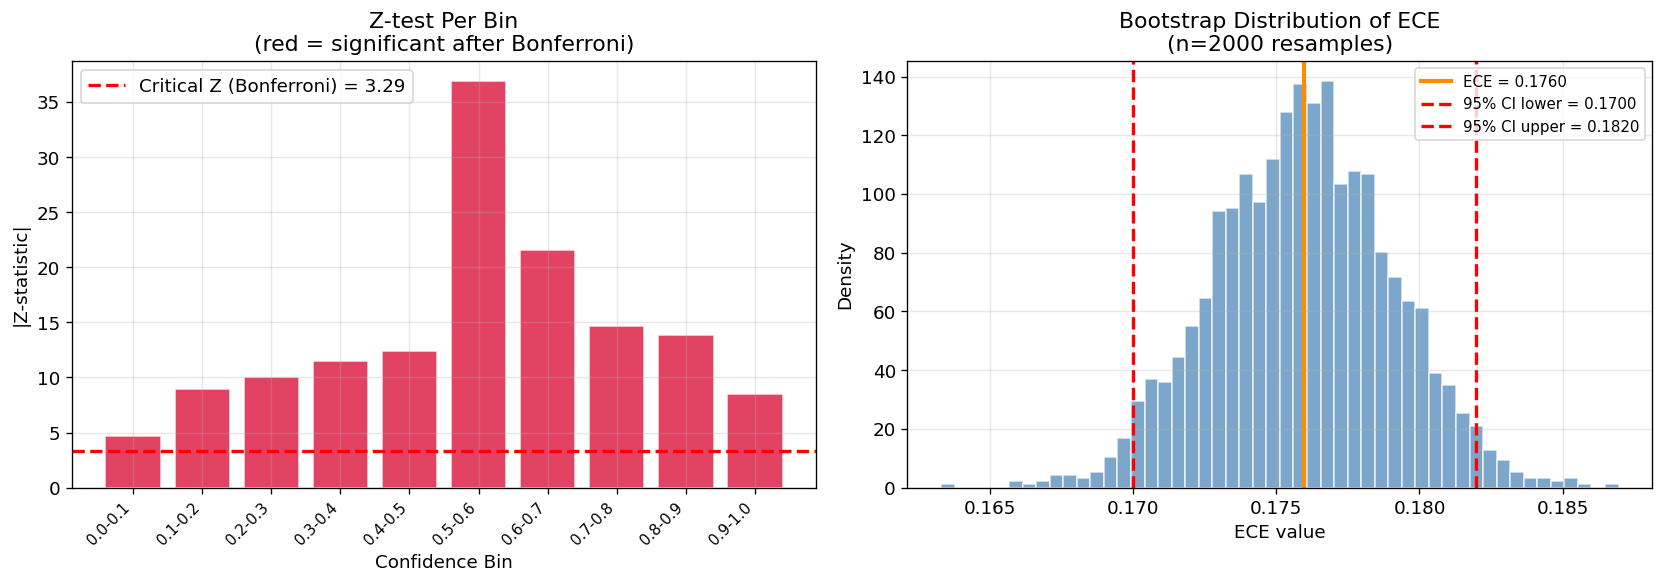

Saved: outputs/plots/04_hypothesis_testing.png


In [7]:
# Plot 1: Z-statistics per bin
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left plot: Z-statistics with significance threshold
ax = axes[0]
colors = ["crimson" if s == "YES ***" else "steelblue"
          for s in ztest_df["Significant"]]
bars = ax.bar(range(len(ztest_df)), ztest_df["Z-stat"].abs(),
              color=colors, alpha=0.8, edgecolor="white")

# Critical Z value for Bonferroni-corrected alpha
critical_z = norm.ppf(1 - bonferroni_alpha/2)
ax.axhline(critical_z, color="red", linestyle="--", linewidth=2,
           label=f"Critical Z (Bonferroni) = {critical_z:.2f}")

ax.set_xticks(range(len(ztest_df)))
ax.set_xticklabels(ztest_df["Bin"], rotation=45, ha="right", fontsize=9)
ax.set_xlabel("Confidence Bin")
ax.set_ylabel("|Z-statistic|")
ax.set_title("Z-test Per Bin\n(red = significant after Bonferroni)")
ax.legend()
ax.grid(True, alpha=0.3)

# Right plot: Bootstrap ECE distribution
ax2 = axes[1]
ax2.hist(ece_dist, bins=50, color="steelblue", alpha=0.7,
         edgecolor="white", density=True)
ax2.axvline(ece_point, color="darkorange", linewidth=2.5,
            label=f"ECE = {ece_point:.4f}")
ax2.axvline(ci_lower, color="red", linewidth=2, linestyle="--",
            label=f"95% CI lower = {ci_lower:.4f}")
ax2.axvline(ci_upper, color="red", linewidth=2, linestyle="--",
            label=f"95% CI upper = {ci_upper:.4f}")
ax2.set_xlabel("ECE value")
ax2.set_ylabel("Density")
ax2.set_title(f"Bootstrap Distribution of ECE\n(n={N_BOOTSTRAP} resamples)")
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("../outputs/plots/04_hypothesis_testing.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Saved: outputs/plots/04_hypothesis_testing.png")